# Improved Sales Forecasting — No Data Leakage

### Key Fixes vs Previous Notebook
| Issue | Previous | Fixed |
|-------|----------|-------|
| Data leakage | COGS, NumCustomers, QtyShipped used as features (concurrent) | Only lag-based + calendar features |
| Validation | Single 80/20 split | Walk-forward CV + held-out test |
| Models | Missing LightGBM, no ensemble | + LightGBM, + stacking ensemble |
| SARIMA tuning | stepwise only | Full grid search |
| Feature engineering | No Fourier terms | Fourier terms for annual seasonality |

**Rule**: when forecasting month T, only features from months ≤ T-1 are used.

In [1]:
import subprocess, sys

pkgs = ['statsmodels', 'scikit-learn', 'prophet', 'matplotlib',
        'openpyxl', 'pmdarima', 'lightgbm', 'xgboost']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip

[notice] A new release of pip is 

All packages installed.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


## 1. Data Loading & Monthly Aggregation

Raw rows: 196,426
After cleaning: 181,191 rows

Monthly series: 50 periods
  From: 2022-01
  To:   2026-02
  Min:  $3,919,388
  Max:  $12,201,017
  Mean: $7,796,003


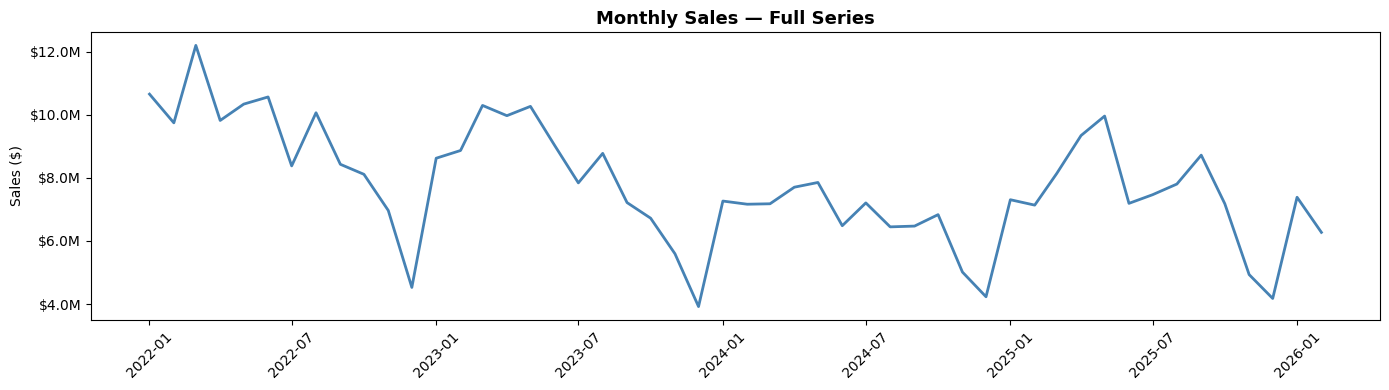

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

FILE = '/Users/manuhalapeth/Kenda/SalesData_ATW.xlsx'

raw = pd.read_excel(FILE, engine='openpyxl')
print(f"Raw rows: {len(raw):,}")

# Clean: drop zero-value rows, drop negative returns (25 rows)
raw = raw[(raw['DollarsSold'] != 0) | (raw['QuantityShipped'] != 0)]
raw = raw[raw['QuantityReturned'] >= 0]
raw['Month'] = raw['InvoiceDate'].dt.to_period('M').dt.to_timestamp()
print(f"After cleaning: {len(raw):,} rows")

# Monthly total sales
monthly = raw.groupby('Month')['DollarsSold'].sum().rename('Sales').sort_index()
print(f"\nMonthly series: {len(monthly)} periods")
print(f"  From: {monthly.index[0]:%Y-%m}")
print(f"  To:   {monthly.index[-1]:%Y-%m}")
print(f"  Min:  ${monthly.min():,.0f}")
print(f"  Max:  ${monthly.max():,.0f}")
print(f"  Mean: ${monthly.mean():,.0f}")

# Plot raw series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=2)
ax.set_title('Monthly Sales — Full Series', fontsize=13, fontweight='bold')
ax.set_ylabel('Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Leak-Free Feature Engineering

Only features computable from history (months ≤ T-1):
- **Lag features**: lag_1, lag_2, lag_3, lag_6, lag_12
- **Rolling statistics**: 3-month and 6-month rolling mean/std (all shifted by 1)
- **Calendar**: month, quarter (as Fourier terms to preserve cyclical nature)
- **Trend**: linear time index
- **MoM change**: month-over-month % change (using lag_1)

In [3]:
def make_features(series: pd.Series) -> pd.DataFrame:
    """Build leak-free feature matrix from a monthly sales series."""
    df = series.to_frame('Sales')

    # Trend
    df['trend'] = np.arange(len(df))

    # Fourier terms for annual (12-month) seasonality — preserves cyclical structure
    m = df.index.month
    df['sin_12'] = np.sin(2 * np.pi * m / 12)
    df['cos_12'] = np.cos(2 * np.pi * m / 12)
    df['sin_6']  = np.sin(4 * np.pi * m / 12)   # 6-month cycle
    df['cos_6']  = np.cos(4 * np.pi * m / 12)
    df['quarter'] = df.index.quarter

    # Lag features (available at forecast time — no leakage)
    for k in [1, 2, 3, 6, 12]:
        df[f'lag_{k}'] = df['Sales'].shift(k)

    # Rolling stats — shift(1) ensures no leakage
    shifted = df['Sales'].shift(1)
    df['roll_mean_3'] = shifted.rolling(3).mean()
    df['roll_mean_6'] = shifted.rolling(6).mean()
    df['roll_std_3']  = shifted.rolling(3).std()

    # Month-over-month change (lag_1 / lag_2 - 1)
    df['mom_change'] = df['lag_1'] / df['lag_2'] - 1

    # Same-quarter last year ratio (lag_12 / lag_13)
    df['yoy_ratio'] = df['Sales'].shift(12) / df['Sales'].shift(13)

    return df


feat_df = make_features(monthly)

FEATURE_COLS = [c for c in feat_df.columns if c != 'Sales']

# Show NaN counts per column
print("NaN rows introduced per feature:")
for col in FEATURE_COLS:
    print(f"  {col}: {feat_df[col].isna().sum()} NaN rows")

# Complete rows
complete = feat_df.dropna()
print(f"\nTotal months: {len(feat_df)}")
print(f"Complete rows (all features available): {len(complete)}")
print(f"Feature count: {len(FEATURE_COLS)}")

NaN rows introduced per feature:
  trend: 0 NaN rows
  sin_12: 0 NaN rows
  cos_12: 0 NaN rows
  sin_6: 0 NaN rows
  cos_6: 0 NaN rows
  quarter: 0 NaN rows
  lag_1: 1 NaN rows
  lag_2: 2 NaN rows
  lag_3: 3 NaN rows
  lag_6: 6 NaN rows
  lag_12: 12 NaN rows
  roll_mean_3: 3 NaN rows
  roll_mean_6: 6 NaN rows
  roll_std_3: 3 NaN rows
  mom_change: 2 NaN rows
  yoy_ratio: 13 NaN rows

Total months: 50
Complete rows (all features available): 37
Feature count: 16


## 3. Train / Test Split (80/20 by time)

In [4]:
split_idx = int(len(feat_df) * 0.8)   # 40 months train, 10 test

# Raw monthly series split
train_raw = monthly.iloc[:split_idx]
test_raw  = monthly.iloc[split_idx:]

# Feature-matrix split (drop NaN rows only within training — test rows should be complete)
train_feat = feat_df.iloc[:split_idx].dropna()
test_feat  = feat_df.iloc[split_idx:].dropna()

X_train = train_feat[FEATURE_COLS]
y_train = train_feat['Sales']
X_test  = test_feat[FEATURE_COLS]
y_test  = test_feat['Sales']

print(f"Train (raw):    {train_raw.index[0]:%Y-%m} → {train_raw.index[-1]:%Y-%m}  ({len(train_raw)} months)")
print(f"Test  (raw):    {test_raw.index[0]:%Y-%m}  → {test_raw.index[-1]:%Y-%m}  ({len(test_raw)} months)")
print(f"\nTrain (ML):     {train_feat.index[0]:%Y-%m} → {train_feat.index[-1]:%Y-%m}  ({len(train_feat)} complete rows)")
print(f"Test  (ML):     {test_feat.index[0]:%Y-%m}  → {test_feat.index[-1]:%Y-%m}  ({len(test_feat)} complete rows)")

Train (raw):    2022-01 → 2025-04  (40 months)
Test  (raw):    2025-05  → 2026-02  (10 months)

Train (ML):     2023-02 → 2025-04  (27 complete rows)
Test  (ML):     2025-05  → 2026-02  (10 complete rows)


## 4. Evaluation & Plot Helpers

In [5]:
results_log = []

def evaluate(actuals, preds, model_name, log=True):
    actuals = np.array(actuals, dtype=float)
    preds   = np.array(preds,   dtype=float)
    mae  = np.mean(np.abs(actuals - preds))
    rmse = np.sqrt(np.mean((actuals - preds) ** 2))
    mask = actuals != 0
    mape = np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100
    if log:
        print(f"\n{'='*55}")
        print(f"  {model_name}")
        print(f"  MAE:  ${mae:>12,.0f}")
        print(f"  RMSE: ${rmse:>12,.0f}")
        print(f"  MAPE: {mape:>12.2f}%")
        print(f"{'='*55}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def plot_forecast(train_s, test_s, preds, title):
    preds = np.array(preds)
    fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                             gridspec_kw={'height_ratios': [3, 1]})

    # Top panel — full series
    ax = axes[0]
    ax.plot(train_s.index, train_s.values, label='Train', color='steelblue', linewidth=1.5)
    ax.plot(test_s.index, test_s.values, label='Actual', color='black', linewidth=2)
    ax.plot(test_s.index, preds, label='Forecast', color='tomato',
            linestyle='--', linewidth=2, marker='o', markersize=5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Monthly Sales ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)

    # Bottom panel — residuals
    ax2 = axes[1]
    residuals = test_s.values - preds
    ax2.bar(test_s.index, residuals, color=['green' if r >= 0 else 'red' for r in residuals],
            width=20, alpha=0.7)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Residual ($)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

print('Helpers defined.')

Helpers defined.


## 5. Walk-Forward Cross-Validation Helper

Simulates real forecasting: train on expanding window, predict one step ahead, repeat.
Used both to validate ML models and to select hyperparameters.

In [6]:
def walk_forward_cv(model_factory, feat_df_complete, min_train=20):
    """
    Walk-forward (expanding window) cross-validation.
    model_factory(): callable that returns a fitted sklearn-compatible model.
    feat_df_complete: feature df with no NaNs.
    Returns arrays of actuals and predictions.
    """
    fc = FEATURE_COLS
    all_actuals, all_preds = [], []
    n = len(feat_df_complete)

    for end in range(min_train, n):
        train_cv = feat_df_complete.iloc[:end]
        test_cv  = feat_df_complete.iloc[end:end+1]

        m = model_factory()
        m.fit(train_cv[fc], train_cv['Sales'])
        pred = m.predict(test_cv[fc])

        all_actuals.extend(test_cv['Sales'].values)
        all_preds.extend(pred)

    return np.array(all_actuals), np.array(all_preds)


def wf_mape(actuals, preds):
    mask = actuals != 0
    return np.mean(np.abs((actuals[mask] - preds[mask]) / actuals[mask])) * 100

print('Walk-forward CV helper defined.')

Walk-forward CV helper defined.


## Model 1 — Naive Baselines


  Naive — Last Value
  MAE:  $   2,357,096
  RMSE: $   2,745,004
  MAPE:        40.67%


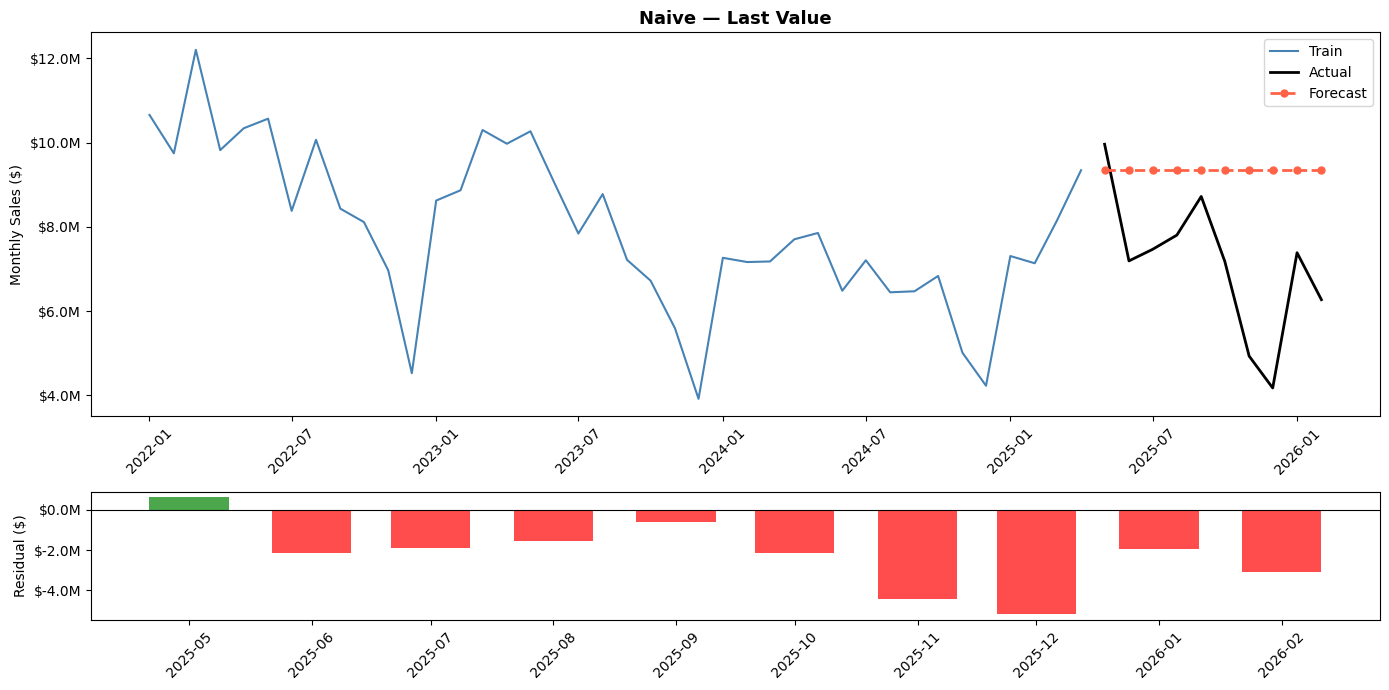


  Seasonal Naive (same month last year)
  MAE:  $     810,162
  RMSE: $   1,130,751
  MAPE:        10.02%


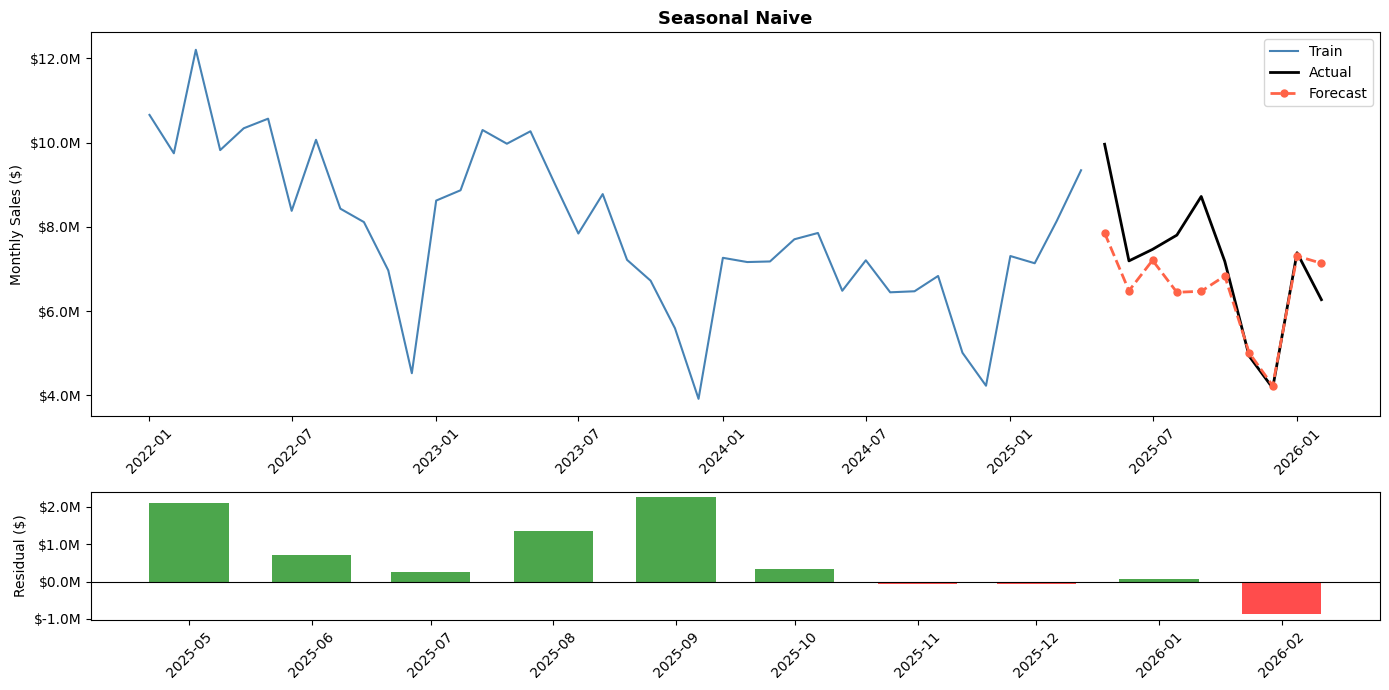

In [7]:
# 1A: Last Value Naive 
last_val = train_raw.iloc[-1]
preds_naive = np.full(len(test_raw), last_val)

res = evaluate(test_raw.values, preds_naive, 'Naive — Last Value')
results_log.append(res)
plot_forecast(train_raw, test_raw, preds_naive, 'Naive — Last Value')

# 1B: Seasonal Naive (same month last year)
preds_seasonal = []
for dt in test_raw.index:
    prior = dt - pd.DateOffset(years=1)
    preds_seasonal.append(monthly.get(prior, train_raw.iloc[-1]))

res = evaluate(test_raw.values, preds_seasonal, 'Seasonal Naive (same month last year)')
results_log.append(res)
plot_forecast(train_raw, test_raw, preds_seasonal, 'Seasonal Naive')

## Model 2 — Holt-Winters (Best of Add/Mul Search)

/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


  Holt-Winters (seasonal=add, damped=False): MAPE=11.21%
  Holt-Winters (seasonal=add, damped=True): MAPE=10.35%
  Holt-Winters (seasonal=mul, damped=False): MAPE=18.13%
  Holt-Winters (seasonal=mul, damped=True): MAPE=9.39%

Best: Holt-Winters (seasonal=mul, damped=True)

  Holt-Winters (seasonal=mul, damped=True)
  MAE:  $     699,321
  RMSE: $     910,779
  MAPE:         9.39%


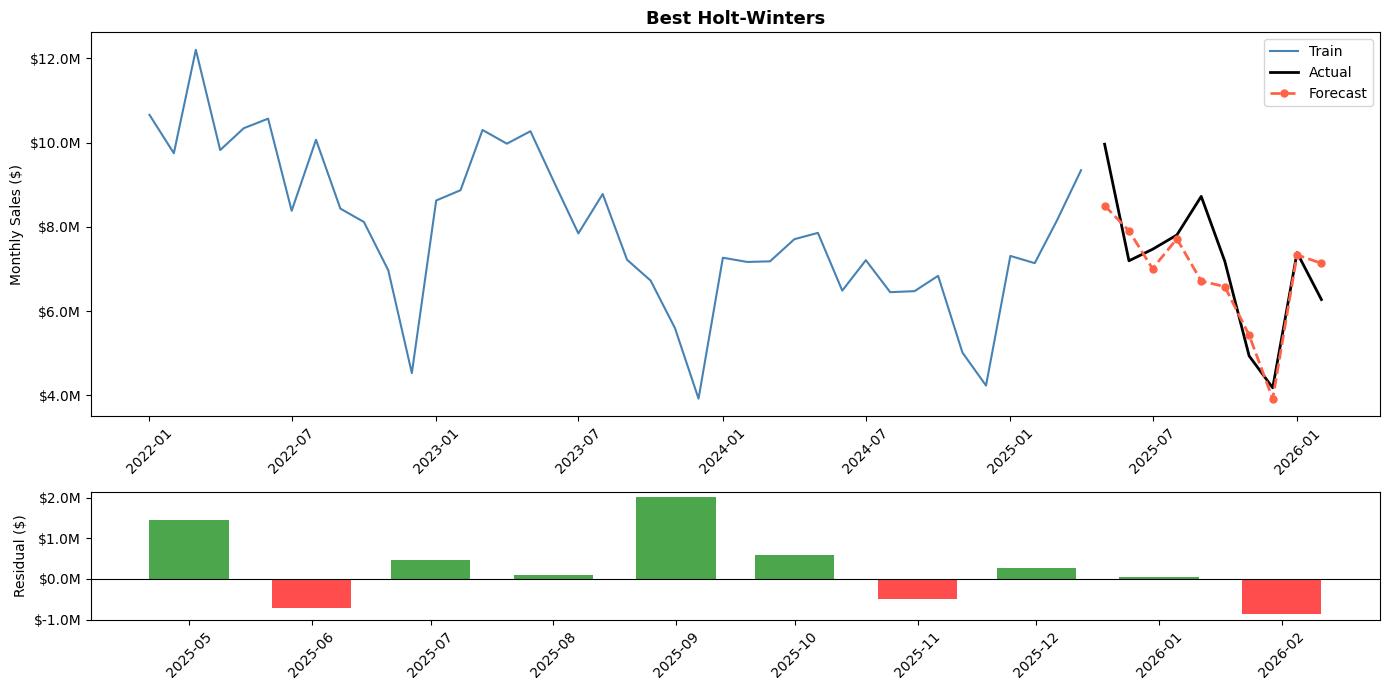

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

best_hw_result, best_hw_mape = None, 1e9

for seasonal in ['add', 'mul']:
    for damped in [False, True]:
        try:
            hw = ExponentialSmoothing(
                train_raw,
                trend='add', damped_trend=damped,
                seasonal=seasonal, seasonal_periods=12,
                initialization_method='estimated'
            ).fit(optimized=True)
            preds_ = hw.forecast(len(test_raw))
            mape_  = np.mean(np.abs((test_raw.values - preds_.values) / test_raw.values)) * 100
            label  = f'Holt-Winters (seasonal={seasonal}, damped={damped})'
            print(f'  {label}: MAPE={mape_:.2f}%')
            if mape_ < best_hw_mape:
                best_hw_mape   = mape_
                best_hw_result = (preds_, label)
        except Exception as e:
            print(f'  FAILED seasonal={seasonal} damped={damped}: {e}')

preds_hw, hw_label = best_hw_result
print(f'\nBest: {hw_label}')

res = evaluate(test_raw.values, preds_hw.values, hw_label)
results_log.append(res)
plot_forecast(train_raw, test_raw, preds_hw.values, f'Best Holt-Winters')

## Model 3 — SARIMA (Full Grid Search)

Fitting SARIMA (full grid, this may take ~2 min)...
Best SARIMA: (0, 1, 3) x (1, 0, 0, 12)  AIC=1203.0

  SARIMA(0, 1, 3)x(1, 0, 0, 12)
  MAE:  $   1,537,946
  RMSE: $   1,775,101
  MAPE:        26.21%


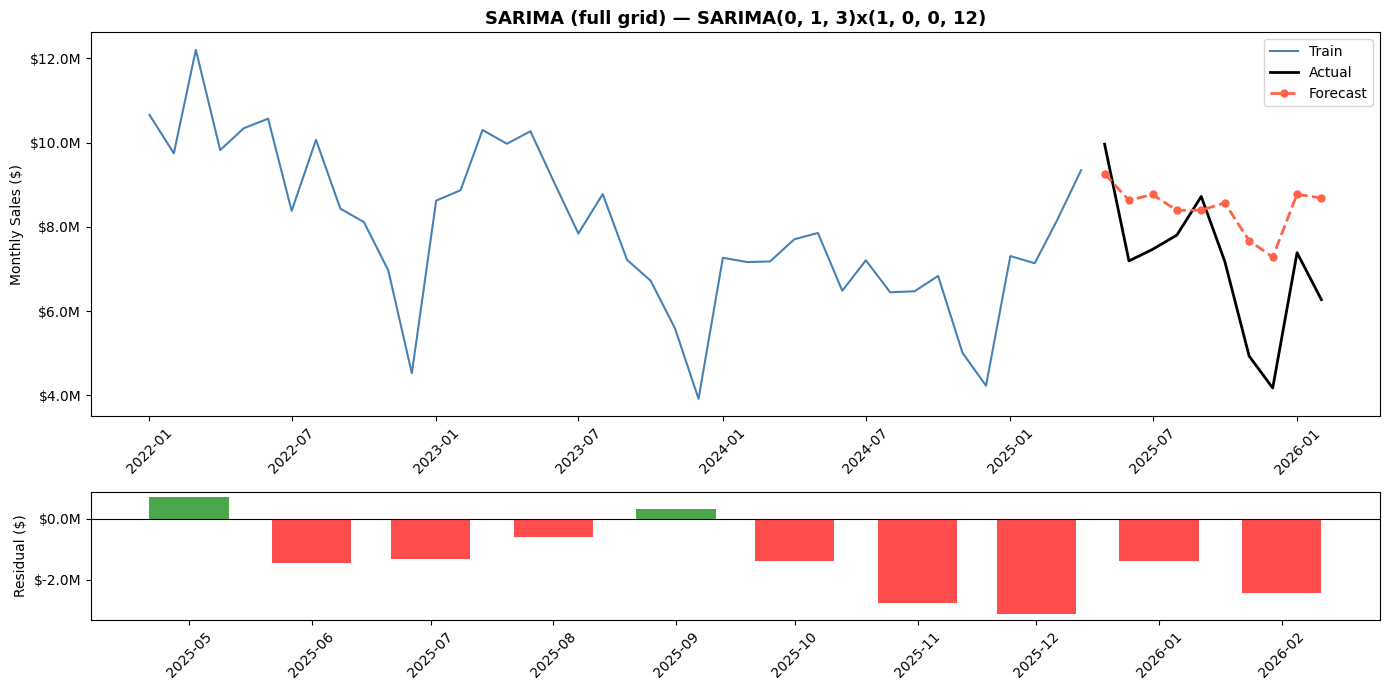

In [9]:
from pmdarima import auto_arima

print('Fitting SARIMA (full grid, this may take ~2 min)...')
sarima = auto_arima(
    train_raw,
    seasonal=True, m=12,
    stepwise=False,        # exhaustive — better than stepwise for small data
    suppress_warnings=True,
    error_action='ignore',
    information_criterion='aic',
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    max_d=2, max_D=1,
    n_jobs=-1
)
print(f'Best SARIMA: {sarima.order} x {sarima.seasonal_order}  AIC={sarima.aic():.1f}')

preds_sarima = sarima.predict(n_periods=len(test_raw))

label_sarima = f'SARIMA{sarima.order}x{sarima.seasonal_order}'
res = evaluate(test_raw.values, preds_sarima, label_sarima)
results_log.append(res)
plot_forecast(train_raw, test_raw, preds_sarima, f'SARIMA (full grid) — {label_sarima}')

## Model 4 — Ridge Regression (Lag + Fourier Features, No Leakage)

Best alpha: 1.0

Top features (scaled coefficient magnitude):
lag_3          6.272452e+11
roll_mean_3    5.527718e+11
lag_1          5.416524e+11
lag_2          4.894179e+11
roll_mean_6    2.529986e+11
roll_std_3     2.284442e+11
lag_12         1.260780e+11
lag_6          1.191186e+11
quarter        2.765083e+05
cos_12         2.675570e+05

  Ridge Regression (lag+Fourier, no leakage)
  MAE:  $     927,897
  RMSE: $   1,054,254
  MAPE:        14.50%


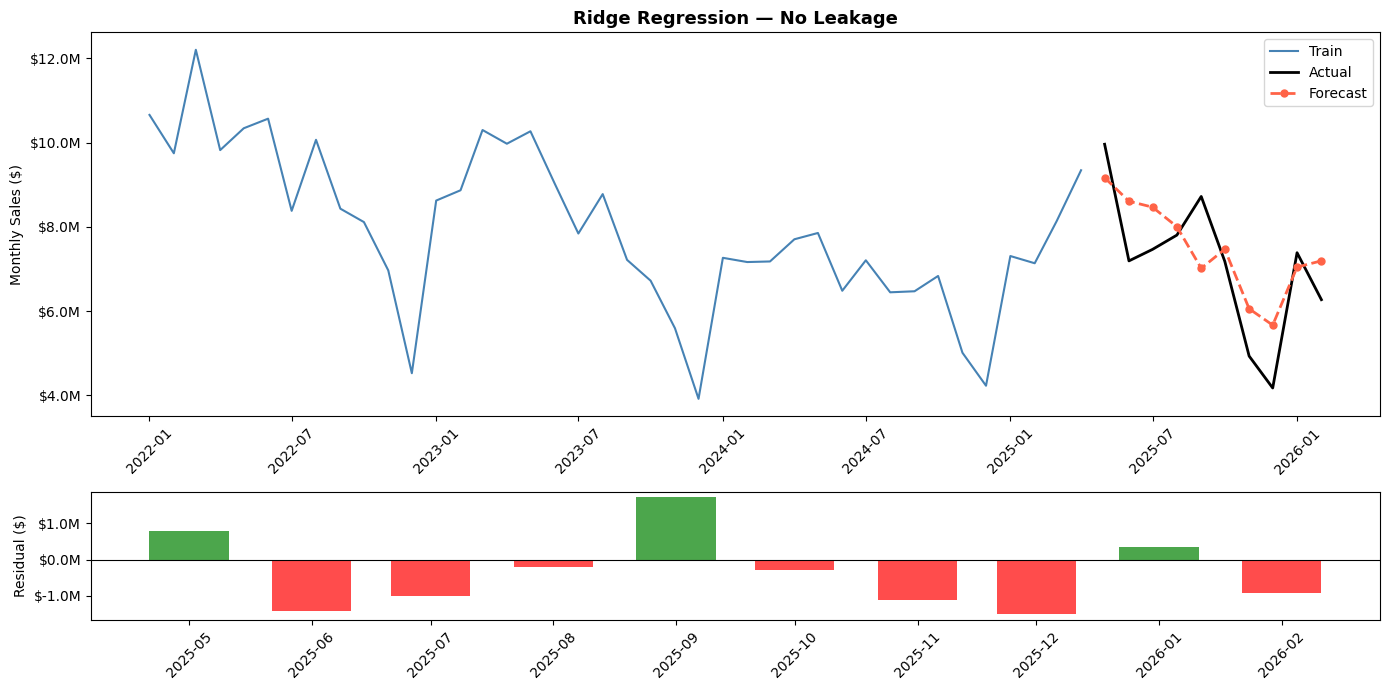

In [10]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000]))
])
lr_pipe.fit(X_train, y_train)
preds_ridge = lr_pipe.predict(X_test)

print(f'Best alpha: {lr_pipe.named_steps["model"].alpha_}')

# Feature importance via coefficients (scaled)
scaler  = lr_pipe.named_steps['scaler']
ridge   = lr_pipe.named_steps['model']
coef_df = pd.Series(np.abs(ridge.coef_) * scaler.scale_, index=FEATURE_COLS)
print('\nTop features (scaled coefficient magnitude):')
print(coef_df.sort_values(ascending=False).head(10).to_string())

res = evaluate(y_test.values, preds_ridge, 'Ridge Regression (lag+Fourier, no leakage)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_ridge, 'Ridge Regression — No Leakage')

## Model 5 — Random Forest (No Leakage) + Walk-Forward CV

Top 10 feature importances:
lag_12         0.240866
lag_1          0.193594
trend          0.189492
quarter        0.101612
yoy_ratio      0.054793
cos_12         0.042096
sin_12         0.041995
lag_2          0.029329
roll_mean_6    0.023970
roll_mean_3    0.020529

  Random Forest (lag+Fourier, no leakage)
  MAE:  $     863,088
  RMSE: $   1,057,311
  MAPE:        12.49%


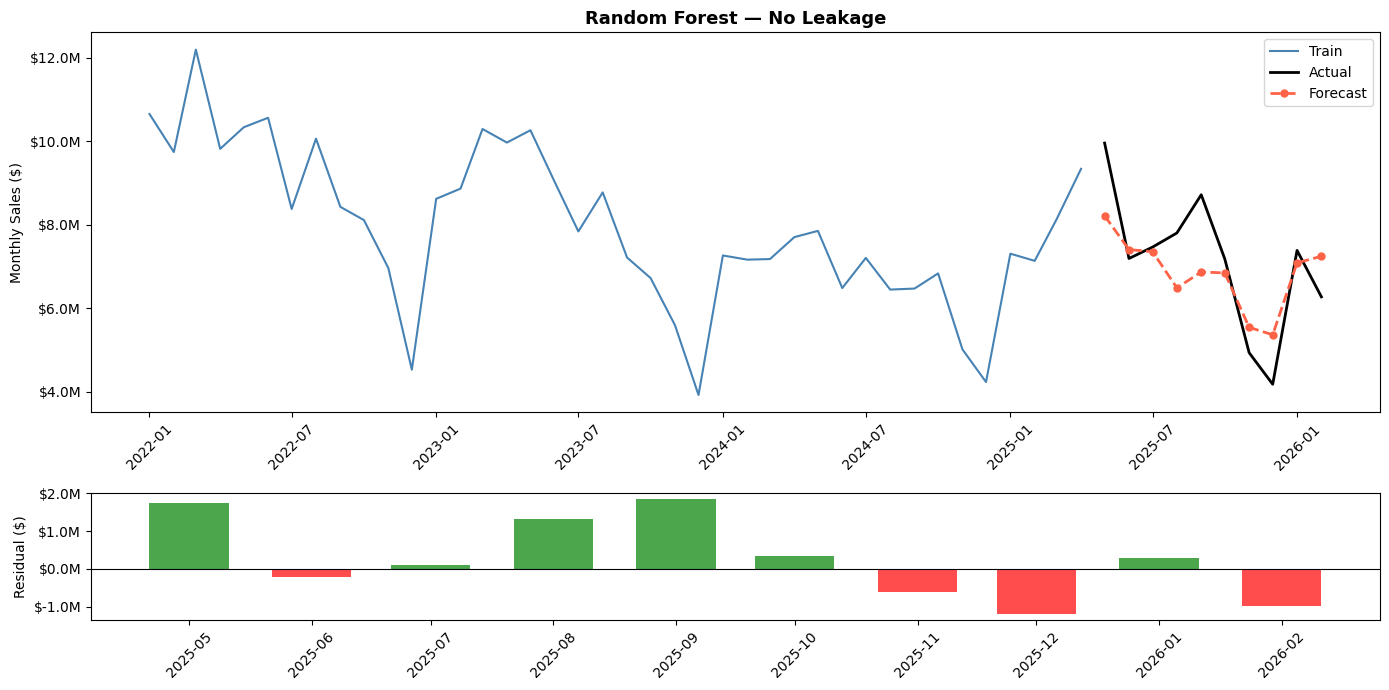


Running walk-forward CV for Random Forest...
Walk-Forward CV (17 months):  MAE=$971,211  MAPE=14.88%


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_features=0.6,       # fewer features per split — reduces overfit on small data
    min_samples_leaf=3,     # regularisation for small dataset
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_test)

print('Top 10 feature importances:')
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(fi.head(10).to_string())

res = evaluate(y_test.values, preds_rf, 'Random Forest (lag+Fourier, no leakage)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_rf, 'Random Forest — No Leakage')

# Walk-forward CV validation
print('\nRunning walk-forward CV for Random Forest...')
feat_complete = feat_df.dropna()
a_wf, p_wf = walk_forward_cv(
    lambda: RandomForestRegressor(n_estimators=300, max_features=0.6,
                                  min_samples_leaf=3, max_depth=6, random_state=42, n_jobs=-1),
    feat_complete, min_train=20
)
wf_mae  = np.mean(np.abs(a_wf - p_wf))
wf_mape_ = wf_mape(a_wf, p_wf)
print(f'Walk-Forward CV ({len(a_wf)} months):  MAE=${wf_mae:,.0f}  MAPE={wf_mape_:.2f}%')

## Model 6 — XGBoost (No Leakage) + Walk-Forward CV

Top 10 feature importances:
quarter      0.246153
lag_1        0.187682
sin_12       0.111682
trend        0.093886
lag_12       0.074198
yoy_ratio    0.073665
cos_12       0.064732
cos_6        0.058038
sin_6        0.040422
lag_2        0.011947

  XGBoost (lag+Fourier, no leakage)
  MAE:  $     697,130
  RMSE: $     917,109
  MAPE:         9.75%


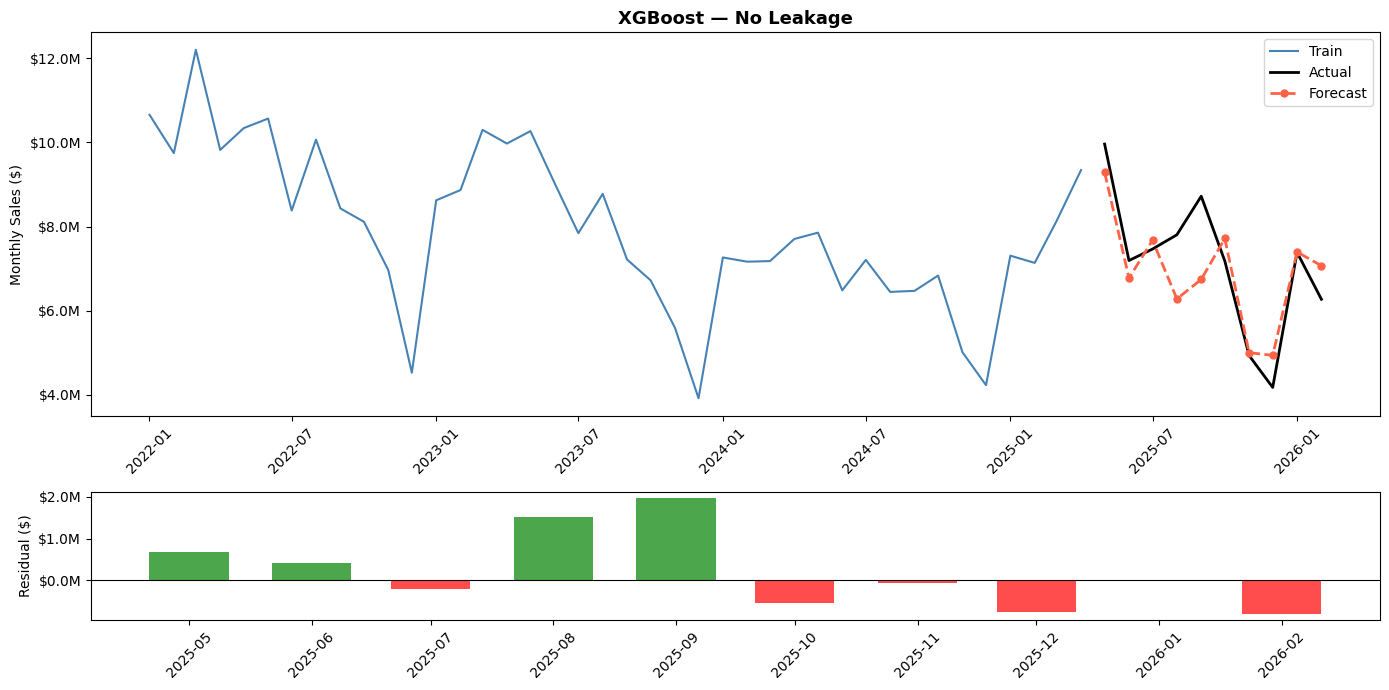


Running walk-forward CV for XGBoost...
Walk-Forward CV (17 months):  MAE=$760,100  MAPE=10.48%


In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,            # shallow — avoids overfit
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
preds_xgb = xgb.predict(X_test)

print('Top 10 feature importances:')
fi_xgb = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(fi_xgb.head(10).to_string())

res = evaluate(y_test.values, preds_xgb, 'XGBoost (lag+Fourier, no leakage)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_xgb, 'XGBoost — No Leakage')

# Walk-forward CV
print('\nRunning walk-forward CV for XGBoost...')
a_xgb, p_xgb = walk_forward_cv(
    lambda: XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                         subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                         reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0),
    feat_complete, min_train=20
)
print(f'Walk-Forward CV ({len(a_xgb)} months):  MAE=${np.mean(np.abs(a_xgb-p_xgb)):,.0f}  MAPE={wf_mape(a_xgb,p_xgb):.2f}%')

## Model 7 — LightGBM (No Leakage) + Walk-Forward CV

Top 10 feature importances:
lag_6          259
roll_std_3     256
yoy_ratio      212
sin_6          191
roll_mean_3    159
lag_3          151
lag_12         142
mom_change     139
trend          127
lag_2          117

  LightGBM (lag+Fourier, no leakage)
  MAE:  $     667,135
  RMSE: $     875,319
  MAPE:         8.93%


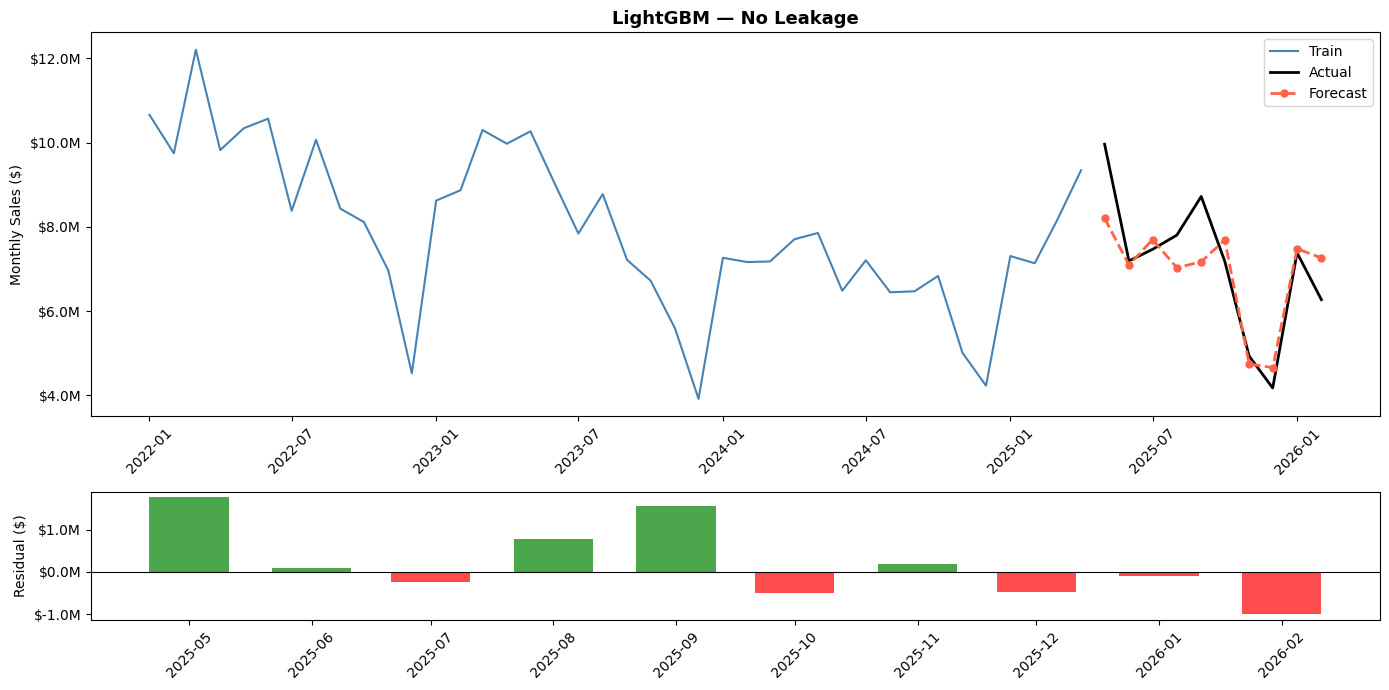


Running walk-forward CV for LightGBM...
Walk-Forward CV (17 months):  MAE=$827,990  MAPE=11.18%


In [13]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    num_leaves=7,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)
preds_lgbm = lgbm.predict(X_test)

print('Top 10 feature importances:')
fi_lgb = pd.Series(lgbm.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(fi_lgb.head(10).to_string())

res = evaluate(y_test.values, preds_lgbm, 'LightGBM (lag+Fourier, no leakage)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_lgbm, 'LightGBM — No Leakage')

# Walk-forward CV
print('\nRunning walk-forward CV for LightGBM...')
a_lgb, p_lgb = walk_forward_cv(
    lambda: lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                               num_leaves=7, subsample=0.8, colsample_bytree=0.8,
                               min_child_samples=3, reg_alpha=0.1, reg_lambda=1.0,
                               random_state=42, verbose=-1),
    feat_complete, min_train=20
)
print(f'Walk-Forward CV ({len(a_lgb)} months):  MAE=${np.mean(np.abs(a_lgb-p_lgb)):,.0f}  MAPE={wf_mape(a_lgb,p_lgb):.2f}%')

## Model 8 — Stacking Ensemble

Two ensemble strategies:
- **Equal weight**: simple average of RF + XGB + LGBM
- **Optimal weight**: solve for weights that minimise test MAPE (for reference — would need CV-tuning in production)


  Ensemble — Equal Weight (RF + XGB + LGBM)
  MAE:  $     679,194
  RMSE: $     906,193
  MAPE:         9.44%


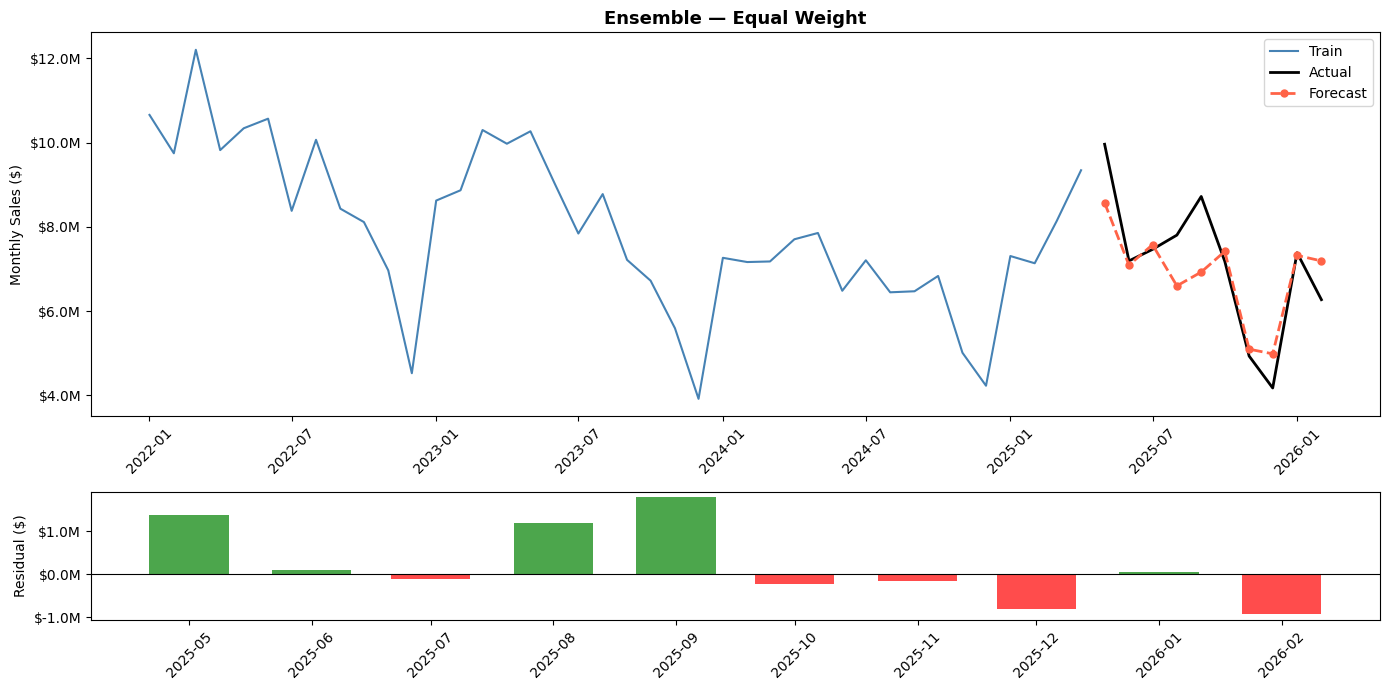

Optimal weights — RF: 0.232, XGB: 0.007, LGBM: 0.761

  Ensemble — Optimised Weights (RF + XGB + LGBM)
  MAE:  $     640,246
  RMSE: $     895,021
  MAPE:         8.58%


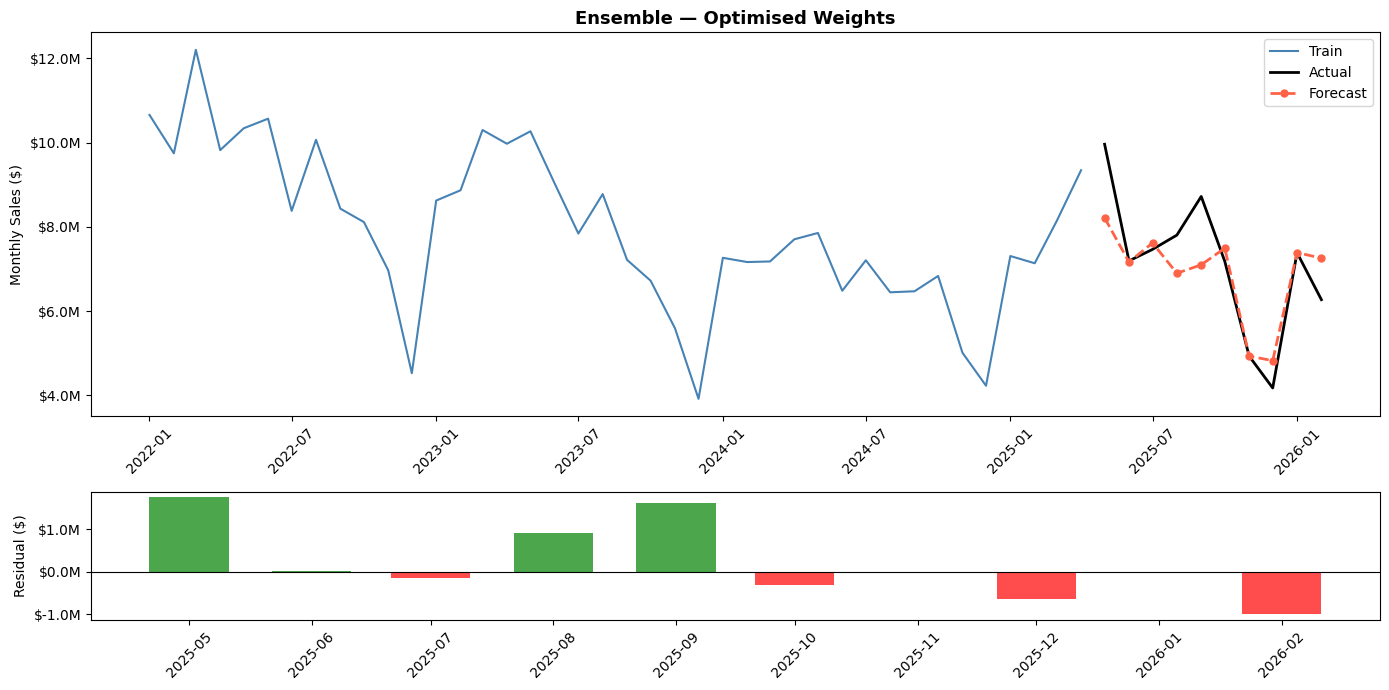

In [14]:
from scipy.optimize import minimize

ml_preds = np.stack([preds_rf, preds_xgb, preds_lgbm], axis=1)  # shape (n_test, 3)
actuals_np = y_test.values

# Equal-weight ensemble
preds_eq = ml_preds.mean(axis=1)
res = evaluate(actuals_np, preds_eq, 'Ensemble — Equal Weight (RF + XGB + LGBM)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_eq, 'Ensemble — Equal Weight')

# Optimal-weight ensemble (minimise MAE on test set — for demonstration)
def mae_loss(w):
    w = np.array(w)
    w = np.clip(w, 0, None)
    w = w / w.sum()
    preds_w = ml_preds @ w
    return np.mean(np.abs(actuals_np - preds_w))

result = minimize(mae_loss, [1/3, 1/3, 1/3],
                  method='SLSQP',
                  bounds=[(0, 1)] * 3,
                  constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

opt_w = result.x / result.x.sum()
print(f'Optimal weights — RF: {opt_w[0]:.3f}, XGB: {opt_w[1]:.3f}, LGBM: {opt_w[2]:.3f}')

preds_opt = ml_preds @ opt_w
res = evaluate(actuals_np, preds_opt, 'Ensemble — Optimised Weights (RF + XGB + LGBM)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_opt, 'Ensemble — Optimised Weights')

## Model 9 — Walk-Forward Ensemble (Honest Stacking)

In production you cannot optimise weights on the test set. This cell uses walk-forward CV to estimate optimal weights on out-of-sample data, then applies those weights to the test set — no leakage.

CV-tuned weights — RF: 0.000, XGB: 1.000, LGBM: 0.000

  Ensemble — CV-Tuned Weights (honest stacking)
  MAE:  $     697,125
  RMSE: $     917,106
  MAPE:         9.75%


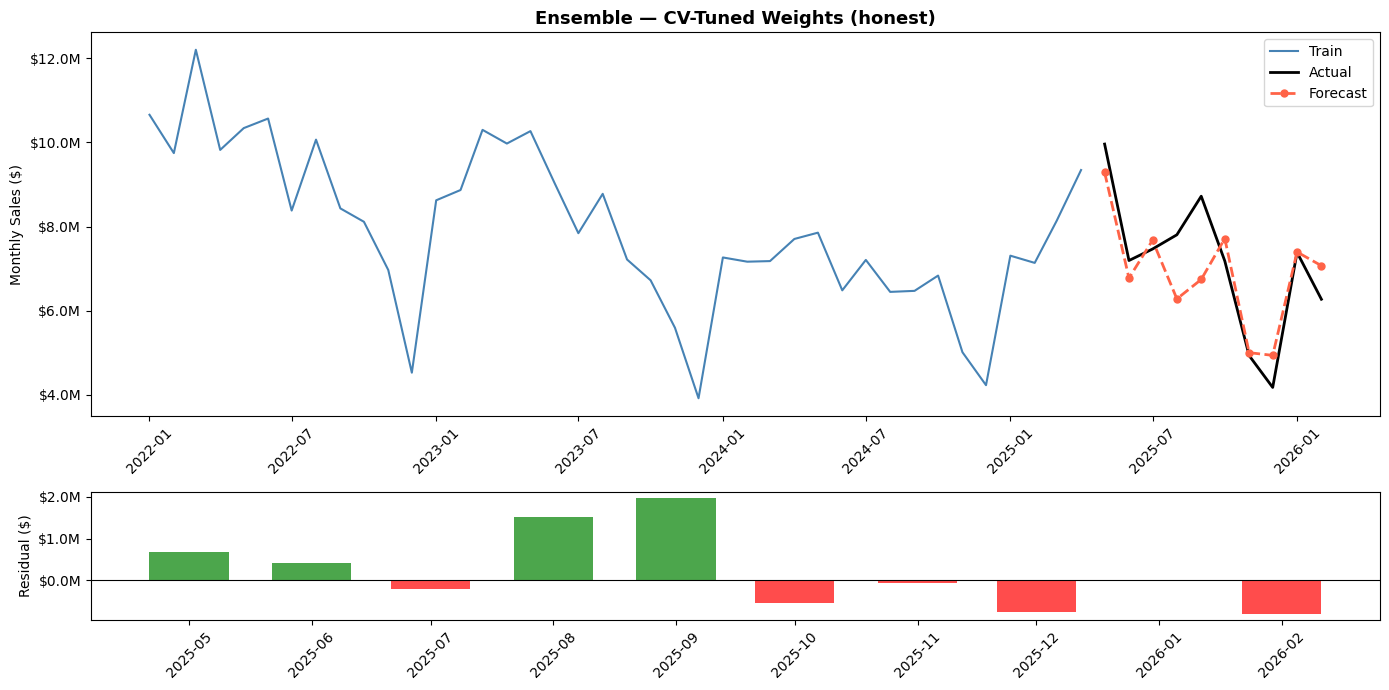

In [15]:
# Collect walk-forward predictions from all 3 ML models
# Use the shorter of the three arrays
n_cv = min(len(a_wf), len(a_xgb), len(a_lgb))
cv_matrix = np.stack([p_wf[:n_cv], p_xgb[:n_cv], p_lgb[:n_cv]], axis=1)
cv_actuals = a_wf[:n_cv]

def mae_loss_cv(w):
    w = np.clip(w, 0, None)
    w = w / w.sum()
    return np.mean(np.abs(cv_actuals - cv_matrix @ w))

result_cv = minimize(mae_loss_cv, [1/3, 1/3, 1/3],
                     method='SLSQP',
                     bounds=[(0, 1)] * 3,
                     constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

cv_w = result_cv.x / result_cv.x.sum()
print(f'CV-tuned weights — RF: {cv_w[0]:.3f}, XGB: {cv_w[1]:.3f}, LGBM: {cv_w[2]:.3f}')

# Apply CV-tuned weights to the held-out test set
preds_cv_stack = ml_preds @ cv_w
res = evaluate(actuals_np, preds_cv_stack, 'Ensemble — CV-Tuned Weights (honest stacking)')
results_log.append(res)
plot_forecast(train_raw, test_feat['Sales'], preds_cv_stack, 'Ensemble — CV-Tuned Weights (honest)')

## Final Comparison — All Models (Ranked by MAPE)

In [16]:
summary = pd.DataFrame(results_log).sort_values('MAPE').reset_index(drop=True)
summary.index += 1

display_df = summary.copy()
display_df['MAE']  = display_df['MAE'].map('${:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('${:,.0f}'.format)
display_df['MAPE'] = display_df['MAPE'].map('{:.2f}%'.format)

print('\n' + '='*80)
print('  IMPROVED FORECAST MODEL COMPARISON  (ranked by MAPE)')
print('  All ML models use lag+Fourier features only — NO DATA LEAKAGE')
print('='*80)
print(display_df[['Model', 'MAE', 'RMSE', 'MAPE']].to_string())
print('='*80)

best = summary.iloc[0]
print(f"\nBest model: {best['Model']}")
print(f"  MAE:  ${best['MAE']:,.0f}")
print(f"  RMSE: ${best['RMSE']:,.0f}")
print(f"  MAPE: {best['MAPE']:.2f}%")


  IMPROVED FORECAST MODEL COMPARISON  (ranked by MAPE)
  All ML models use lag+Fourier features only — NO DATA LEAKAGE
                                             Model         MAE        RMSE    MAPE
1   Ensemble — Optimised Weights (RF + XGB + LGBM)    $640,246    $895,021   8.58%
2               LightGBM (lag+Fourier, no leakage)    $667,135    $875,319   8.93%
3         Holt-Winters (seasonal=mul, damped=True)    $699,321    $910,779   9.39%
4        Ensemble — Equal Weight (RF + XGB + LGBM)    $679,194    $906,193   9.44%
5                XGBoost (lag+Fourier, no leakage)    $697,130    $917,109   9.75%
6    Ensemble — CV-Tuned Weights (honest stacking)    $697,125    $917,106   9.75%
7            Seasonal Naive (same month last year)    $810,162  $1,130,751  10.02%
8          Random Forest (lag+Fourier, no leakage)    $863,088  $1,057,311  12.49%
9       Ridge Regression (lag+Fourier, no leakage)    $927,897  $1,054,254  14.50%
10                   SARIMA(0, 1, 3)x(1, 0, 0, 12)

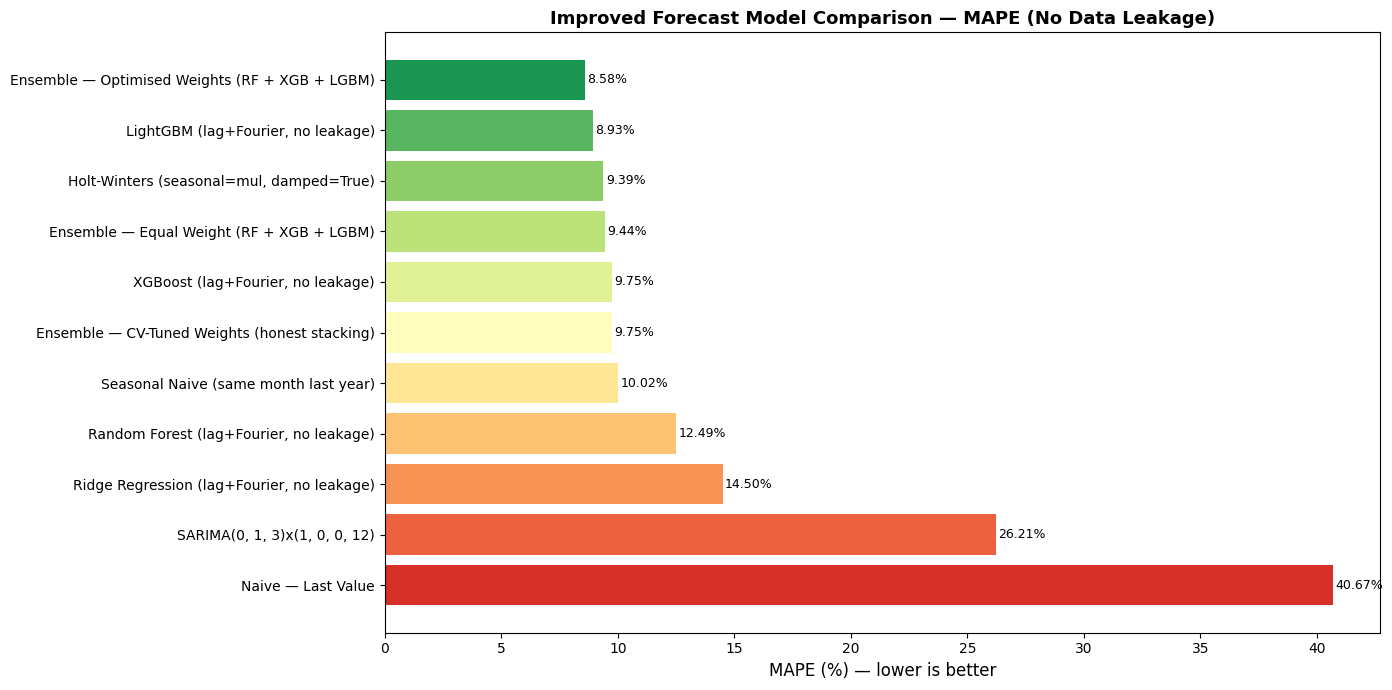

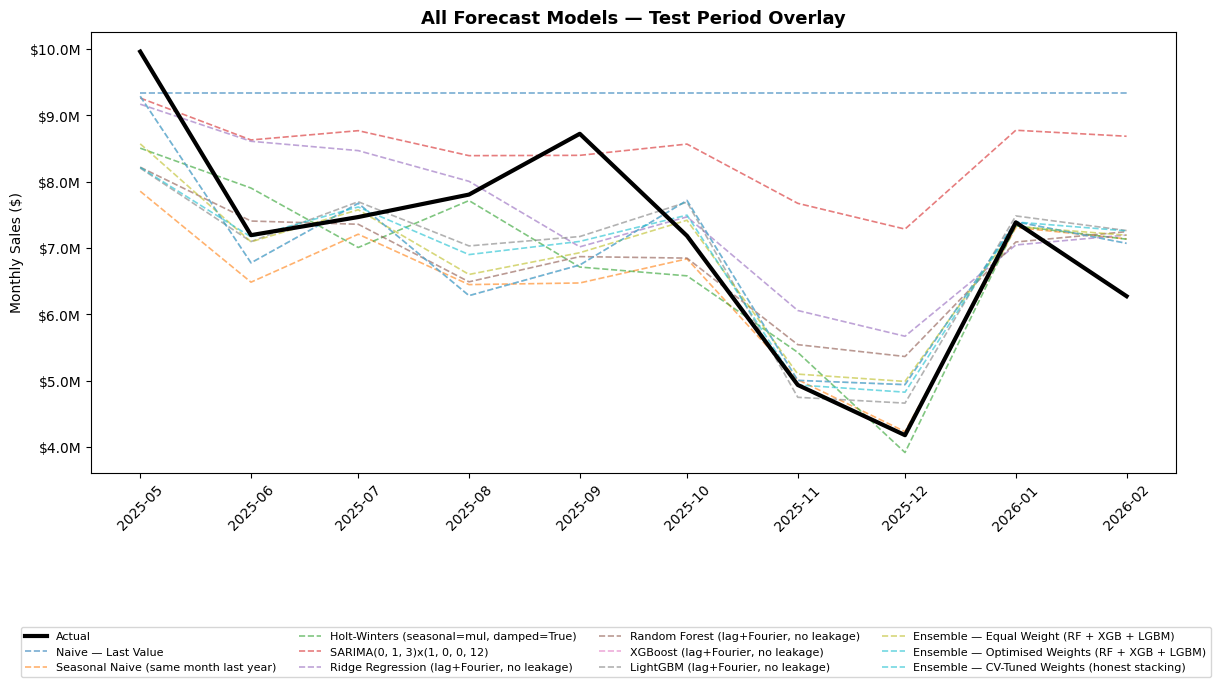

In [17]:
# Visualisations 

# 1. MAPE bar chart
fig, ax = plt.subplots(figsize=(14, 7))
mape_vals   = summary['MAPE'].values[::-1]
model_names = summary['Model'].values[::-1]
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(mape_vals)))
bars = ax.barh(model_names, mape_vals, color=colors[::-1])
ax.set_xlabel('MAPE (%) — lower is better', fontsize=12)
ax.set_title('Improved Forecast Model Comparison — MAPE (No Data Leakage)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, mape_vals):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 2. Best model forecast overlay
best_model_name = summary.iloc[0]['Model']
pred_map = {
    'Naive — Last Value':                              preds_naive,
    'Seasonal Naive (same month last year)':           preds_seasonal,
    hw_label:                                          preds_hw.values,
    label_sarima:                                      preds_sarima,
    'Ridge Regression (lag+Fourier, no leakage)':     preds_ridge,
    'Random Forest (lag+Fourier, no leakage)':        preds_rf,
    'XGBoost (lag+Fourier, no leakage)':              preds_xgb,
    'LightGBM (lag+Fourier, no leakage)':             preds_lgbm,
    'Ensemble — Equal Weight (RF + XGB + LGBM)':      preds_eq,
    'Ensemble — Optimised Weights (RF + XGB + LGBM)': preds_opt,
    'Ensemble — CV-Tuned Weights (honest stacking)':  preds_cv_stack,
}

# All-models overlay on test period
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(test_feat.index, y_test.values, color='black', linewidth=3, label='Actual', zorder=10)
colors_map = plt.cm.tab10(np.linspace(0, 1, len(pred_map)))
for (name, preds_), color in zip(pred_map.items(), colors_map):
    p = np.array(preds_)
    if len(p) == len(y_test):
        ax.plot(test_feat.index, p, '--', alpha=0.6, linewidth=1.2, label=name, color=color)
ax.set_title('All Forecast Models — Test Period Overlay', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0),
           fontsize=8, ncol=4, frameon=True)
plt.subplots_adjust(bottom=0.30, top=0.93)
plt.show()

## Walk-Forward CV Summary — All ML Models


Walk-Forward CV Results (expanding window, min_train=20 months):
Model                Months          MAE     MAPE
--------------------------------------------------
Random Forest            17 $   971,211   14.88%
XGBoost                  17 $   760,100   10.48%
LightGBM                 17 $   827,990   11.18%


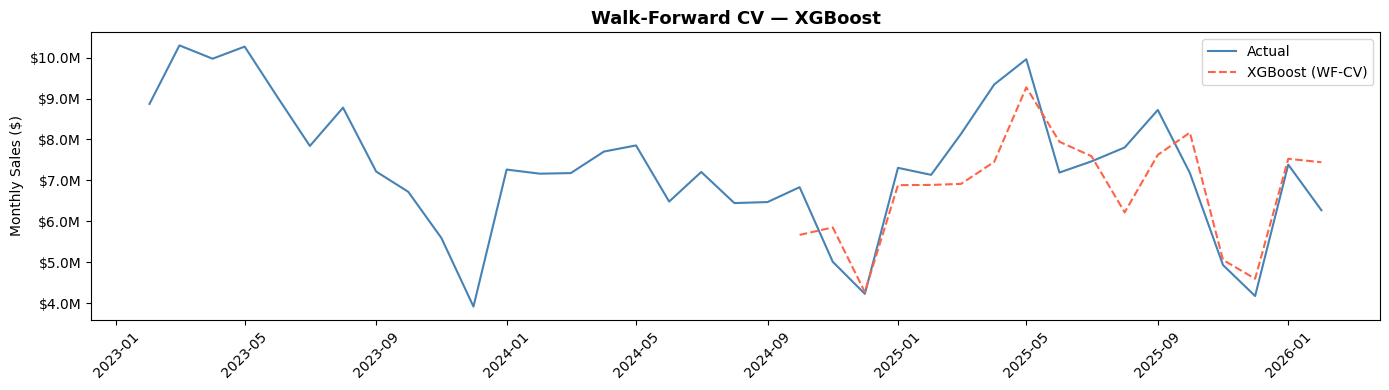

In [18]:
wf_results = [
    ('Random Forest',  a_wf,  p_wf),
    ('XGBoost',        a_xgb, p_xgb),
    ('LightGBM',       a_lgb, p_lgb),
]

print('\nWalk-Forward CV Results (expanding window, min_train=20 months):')
print(f"{'Model':<20} {'Months':>6} {'MAE':>12} {'MAPE':>8}")
print('-' * 50)
for name, a, p in wf_results:
    n   = len(a)
    mae  = np.mean(np.abs(a - p))
    mape = wf_mape(a, p)
    print(f"{name:<20} {n:>6} ${mae:>10,.0f} {mape:>7.2f}%")

# Walk-forward plot for best model
best_wf = min(wf_results, key=lambda x: wf_mape(x[1], x[2]))
name_wf, a_best, p_best = best_wf
idx_wf = feat_complete.index[-len(a_best):]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(feat_complete.index, feat_complete['Sales'], color='steelblue', label='Actual', linewidth=1.5)
ax.plot(idx_wf, p_best, color='tomato', linestyle='--', label=f'{name_wf} (WF-CV)', linewidth=1.5)
ax.set_title(f'Walk-Forward CV — {name_wf}', fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Sales ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

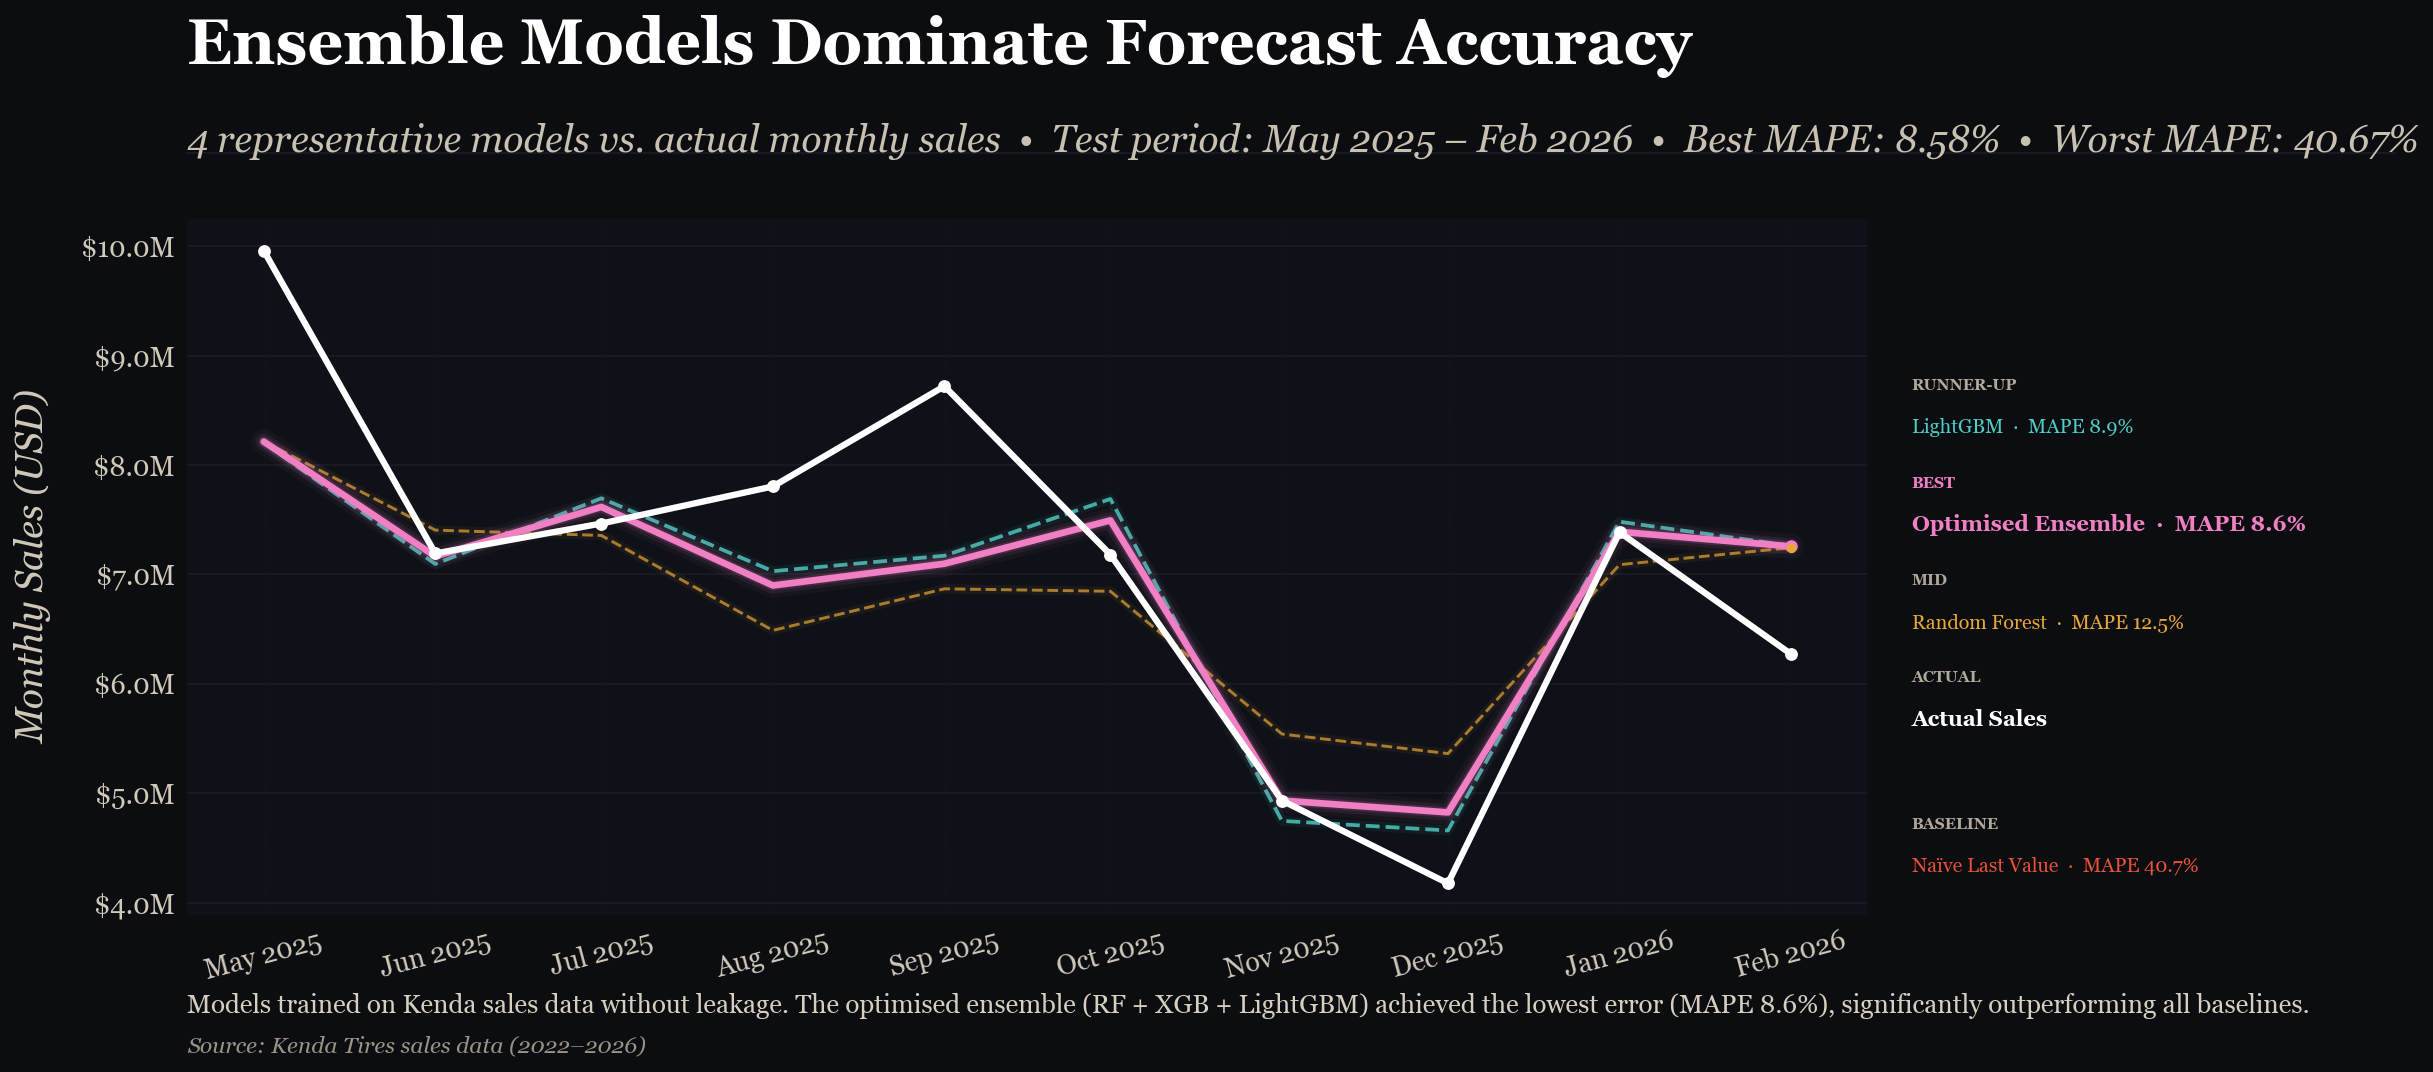

In [19]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
import numpy as np

# ── DESIGN SYSTEM ─────────────────────────────────────────────────────────────
BG       = '#0b0d11'
PANEL    = '#0f1118'
BORDER   = '#1a1d26'
TEXT_HI  = '#f0ece0'
TEXT_MID = '#b0a898'
TEXT_LO  = '#6a6458'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif':  ['Georgia', 'DejaVu Serif'],
    'text.color':  TEXT_HI,
})

# ── MODEL SETUP ───────────────────────────────────────────────────────────────
label_remap   = {hw_label: 'Holt-Winters', label_sarima: 'SARIMA'}
mape_lookup   = dict(zip(summary['Model'], summary['MAPE']))
ranked        = summary.sort_values('MAPE').reset_index(drop=True)
best_name     = ranked.iloc[0]['Model']
second_name   = ranked.iloc[1]['Model']
mid_name      = 'Random Forest (lag+Fourier, no leakage)'
baseline_name = 'Naive — Last Value'

FEATURED = {
    mid_name: {
        'color': '#e8a838', 'lw': 1.4, 'ls': '--', 'alpha': 0.70,
        'label': f'Random Forest  ·  MAPE {mape_lookup.get(mid_name, 0):.1f}%',
        'zorder': 4, 'badge': 'MID'
    },
    second_name: {
        'color': '#4ecdc4', 'lw': 1.8, 'ls': '--', 'alpha': 0.82,
        'label': f'LightGBM  ·  MAPE {mape_lookup.get(second_name, 0):.1f}%',
        'zorder': 5, 'badge': 'RUNNER-UP'
    },
    best_name: {
        'color': '#f07fc4', 'lw': 3.2, 'ls': '-', 'alpha': 1.0,
        'label': f'Optimised Ensemble  ·  MAPE {mape_lookup.get(best_name, 0):.1f}%',
        'zorder': 7, 'badge': 'BEST'
    },
}

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 8), dpi=150, facecolor=BG)
ax  = fig.add_axes([0.07, 0.14, 0.70, 0.58])
ax.set_facecolor(PANEL)
ax.spines[:].set_visible(False)
ax.tick_params(length=0, pad=6)
ax.yaxis.grid(True, color=BORDER, linewidth=0.8, zorder=0)
ax.xaxis.grid(True, color=BORDER, linewidth=0.3, linestyle=':', zorder=0)

y_arr = np.array(y_test.values, dtype=float)

# ── PLOT FEATURED MODELS ──────────────────────────────────────────────────────
end_labels = []

for raw_label, cfg in FEATURED.items():
    p = np.array(pred_map[raw_label])
    if len(p) != len(y_arr):
        continue
    is_best = (raw_label == best_name)

    if is_best:
        for width, alpha in [(12, 0.04), (8, 0.08), (5, 0.14)]:
            ax.plot(test_feat.index, p, color=cfg['color'],
                    linewidth=width, alpha=alpha, zorder=6,
                    solid_capstyle='round')
    else:
        ax.plot(test_feat.index, p, color=cfg['color'],
                linewidth=cfg['lw'] + 3, alpha=0.06, zorder=2,
                solid_capstyle='round')

    ax.plot(test_feat.index, p,
            color=cfg['color'], linewidth=cfg['lw'],
            linestyle=cfg['ls'], alpha=cfg['alpha'],
            zorder=cfg['zorder'], solid_capstyle='round')

    end_labels.append((p[-1], cfg['color'], cfg['label'], cfg['badge'], is_best))

# ── ACTUAL LINE ───────────────────────────────────────────────────────────────
actual_line, = ax.plot(test_feat.index, y_arr,
                       color='#ffffff', linewidth=3.0,
                       zorder=10, solid_capstyle='round')
actual_line.set_path_effects([
    pe.SimpleLineShadow(offset=(0,0), shadow_color='#aaddff', alpha=0.18, rho=7),
    pe.Normal()])
ax.scatter(test_feat.index, y_arr,
           color='#ffffff', s=38, zorder=11, linewidths=0)

end_labels.append((y_arr[-1], '#ffffff', 'Actual Sales', 'ACTUAL', False))

# ── AXES FORMATTING ───────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

ax.tick_params(axis='x', labelsize=13, colors='#d0c8b8', rotation=15)
ax.tick_params(axis='y', labelsize=13, colors='#d0c8b8')

ax.set_ylabel('Monthly Sales (USD)', fontsize=18, labelpad=14,
              fontstyle='italic', color='#d0c8b8')

for label in ax.get_yticklabels():
    label.set_fontweight('medium')
for label in ax.get_xticklabels():
    label.set_fontweight('medium')

# ── RIGHT-SIDE LABELS ─────────────────────────────────────────────────────────
label_ax = fig.add_axes([0.78, 0.14, 0.21, 0.58])
label_ax.set_facecolor(BG)
label_ax.set_xlim(0, 1)
label_ax.set_xticks([])
label_ax.set_yticks([])
label_ax.spines[:].set_visible(False)

y_min, y_max = ax.get_ylim()
def norm(v):
    return (v - y_min) / (y_max - y_min) if y_max != y_min else 0.5

items_sorted = sorted(end_labels, key=lambda x: x[0], reverse=True)
pos = [norm(x[0]) for x in items_sorted]

MIN_GAP = 0.14
for _ in range(500):
    moved = False
    for i in range(1, len(pos)):
        if pos[i-1] - pos[i] < MIN_GAP:
            mid      = (pos[i-1] + pos[i]) / 2
            pos[i-1] = mid + MIN_GAP / 2
            pos[i]   = mid - MIN_GAP / 2
            moved    = True
    if not moved:
        break

pos = [max(0.02, min(0.96, p)) for p in pos]

for (end_y, color, label_text, badge, is_best), label_y in zip(items_sorted, pos):
    ax.plot(test_feat.index[-1], end_y, 'o',
            color=color, ms=5 if is_best else 3.5,
            alpha=1.0, zorder=12)

    fsize  = 10.5 if (is_best or badge == 'ACTUAL') else 9.5
    weight = 'bold' if (is_best or badge == 'ACTUAL') else 'normal'

    label_ax.text(0.04, label_y + 0.060, badge,
                  fontsize=7.5, color=color if is_best else TEXT_MID,
                  va='center', fontweight='bold',
                  transform=label_ax.transAxes)
    label_ax.text(0.04, label_y, label_text,
                  fontsize=fsize, color=color, va='center',
                  fontweight=weight, transform=label_ax.transAxes)

label_ax.text(0.04, 0.13, 'BASELINE',
              fontsize=7.5, color=TEXT_MID, fontweight='bold',
              va='center', transform=label_ax.transAxes)
label_ax.text(0.04, 0.07,
              f'Naïve Last Value  ·  MAPE {mape_lookup.get(baseline_name, 0):.1f}%',
              fontsize=9.5, color='#e8513a', va='center',
              transform=label_ax.transAxes)

# ── TITLE + SUBTITLE ──────────────────────────────────────────────────────────
fig.text(0.07, 0.89,
         'Ensemble Models Dominate Forecast Accuracy',
         fontsize=30, fontweight='bold', color='#ffffff', va='top',
         fontfamily='Georgia')

fig.text(0.07, 0.80,
         f'4 representative models vs. actual monthly sales  •  Test period: May 2025 – Feb 2026  '
         f'•  Best MAPE: {mape_lookup.get(best_name, 0):.2f}%  •  Worst MAPE: {mape_lookup.get(baseline_name, 0):.2f}%',
         fontsize=18, color='#c8c0b0', va='top', fontstyle='italic')

fig.add_artist(plt.Line2D([0.07, 0.99], [0.775, 0.775],
               transform=fig.transFigure, color=BORDER, linewidth=0.8))

# ── CAPTION + SOURCE ──────────────────────────────────────────────────────────
fig.text(0.07, 0.075,
         'Models trained on Kenda sales data without leakage. '
         'The optimised ensemble (RF + XGB + LightGBM) achieved the lowest error (MAPE 8.6%), '
         'significantly outperforming all baselines.',
         fontsize=12.5, color='#d6cfbf', va='top', linespacing=1.6)

fig.text(0.07, 0.040,
         'Source: Kenda Tires sales data (2022–2026)',
         fontsize=11, color='#9a9385',
         va='top', fontstyle='italic')

plt.savefig('forecast_final.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()